## TODO:  HEADER

In [1]:
%load_ext autoreload
%autoreload 2

import nltk

nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

import umap
import pandas as pd
import matplotlib.pyplot as plt

from utils.encoders import *
from utils.preprocess import text_cleaner, pipeline
from utils.utils import visualize_dimensionality_reduction

from lingua import LanguageDetectorBuilder
from deep_translator import GoogleTranslator
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\egorm\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
c:\Users\egorm\miniconda3\envs\tm_masters\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
SEED = 42

# EDA

In [3]:
train_full = pd.read_csv(r"data/train.csv")
train, validation = train_test_split(train_full, 
                                     test_size=0.2, 
                                     stratify=train_full.label,
                                     random_state=SEED
                                     )
test = pd.read_csv(r"data/test.csv", index_col=0)
display(train.sample(3))
display(validation.sample(3))
test.sample(3)

,text,label
6883,Stock market live Wednesday: S&P 500 erases co...,1
2196,Teva prices upsized $2.1B debt offering,2
7912,$SNCA still liking and holding this stock. Wor...,1


,text,label
8398,"At US$69.02, Is It Time To Put ExlService Hold...",2
2010,Vanguard Global ex-U.S. Real Estate ETF declar...,2
9185,$IHG $PK $MAR - Hotels stocks gain as peak pan...,1


,text
id,
1050,"Viomi Technology EPS beats by $0.01, beats on ..."
163,Coronavirus pandemic has driven a very 'ample'...
88,SolarEdge dostarczy Enfindus falowniki dla Eur...


## general

In [4]:
display(train.describe())
train.describe(include="str")

,label
count,7634.000000
mean,1.496201
std,0.743229
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


,text
count,7634
unique,7634
top,Nasdaq prices 600M of 0.875% senior notes
freq,1


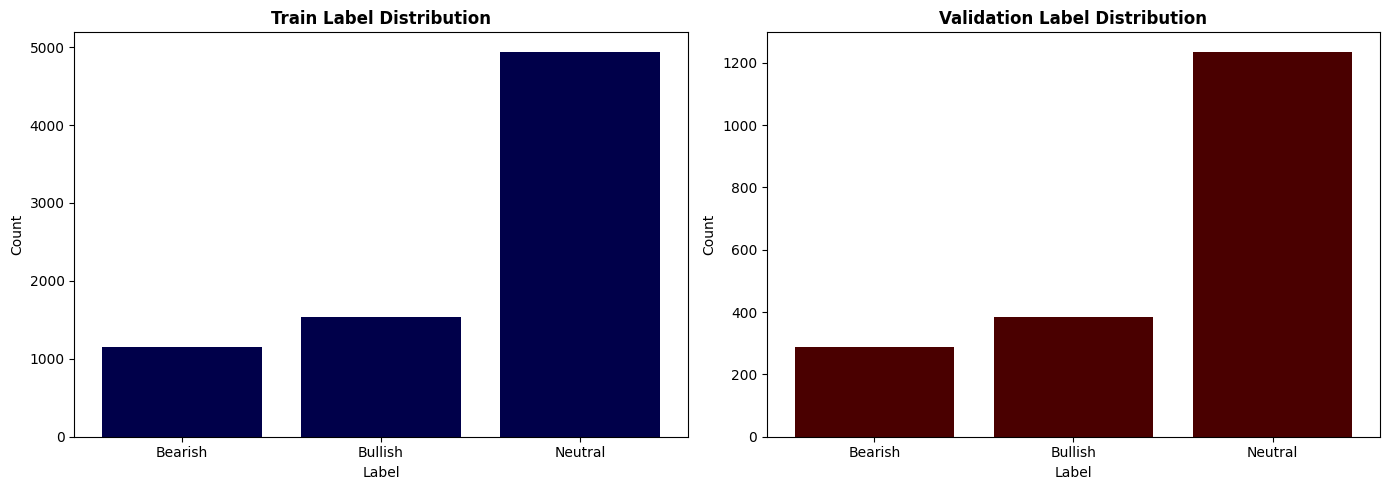

In [5]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=train.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#00004A",
        )

ax[1].bar(x = ["Bearish", "Bullish", "Neutral"],
        height=validation.groupby("label")["text"].count().to_list(), # order by 0, 1, 2
        color="#4A0000",
        )

ax[0].set_xlabel("Label")
ax[0].set_ylabel("Count")
ax[0].set_title(
    "Train Label Distribution", fontweight="bold"
)

ax[1].set_xlabel("Label")
ax[1].set_ylabel("Count")
ax[1].set_title(
    "Validation Label Distribution", fontweight="bold"
)

plt.tight_layout()
plt.savefig(r"plots/correct_split.png")
plt.show()

## Text Overview

### Raw

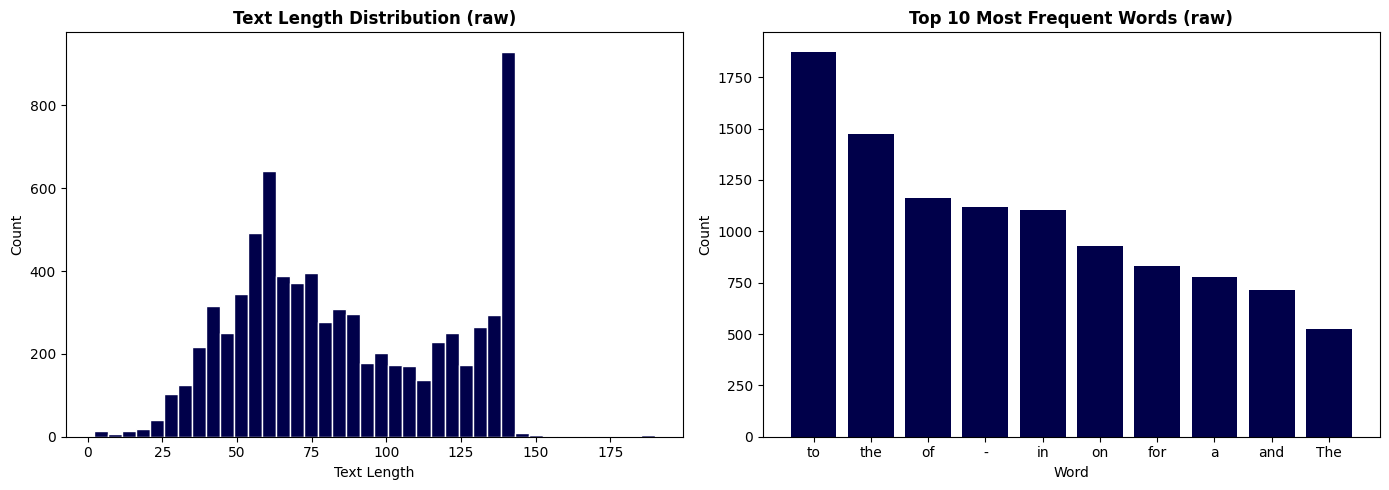

In [6]:
freq_raw = pd.Series(' '.join(train['text']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

ax[0].hist(
         train.text.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )

ax[1].bar(freq_raw.head(10).index, freq_raw.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (raw)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (raw)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/raw_distributions.png")
plt.show()

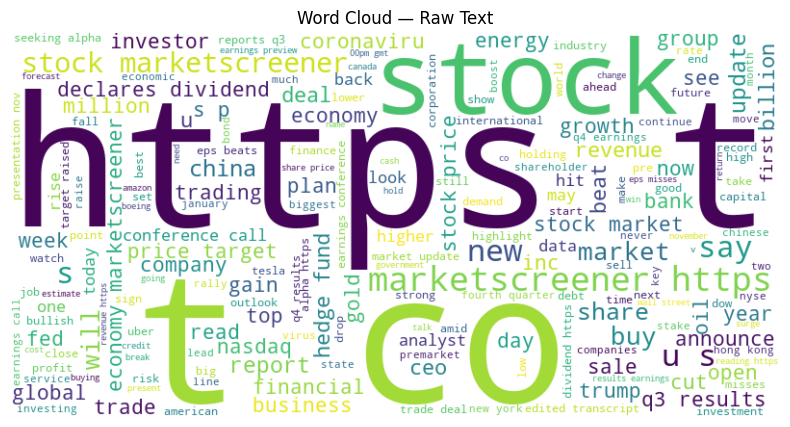

In [7]:
raw_text = ' '.join(train['text']).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Raw Text')
plt.savefig(r"plots/raw_wordcloud.png")
plt.show()

### Cleaning

In [8]:
train["text_clean"] = text_cleaner(train.text)
validation["text_clean"] = text_cleaner(validation.text)

display(train.sample(5))
validation.sample(5)

,text,label,text_clean
661,"Russian and Romanian Rate Decisions, Commodity...",2,russian and romanian rate decisions commodity ...
4934,"NYC HEALTH SPOKESMAN: NO CONFIRMED, SUSPECTED ...",2,nyc health spokesman no confirmed suspected co...
6997,Consumer Next Shoe To Drop As Wall Street Igno...,2,consumer next shoe to drop as wall street igno...
1918,TAAL Announces Appointment of Auditor https://...,2,taal announces appointment of auditor URL
7471,Ireland's finance minister expects two billion...,2,ireland finance minister expects two billion e...


,text,label,text_clean
3292,Dassault Systemes Profit Outlook Lags After Vi...,0,dassault systemes profit outlook lags after vi...
3029,The Danger Of Deeper OPEC+ Cuts https://t.co/5...,0,the danger of deeper opec cuts URL
7809,$ATRS - Antares' Xyosted Is One Of The Best Te...,1,STOCK antares xyosted is one of the best testo...
351,WestRock stock price target raised to $48 from...,1,westrock stock price target raised to 48 from ...
4075,"A take-private is exactly what it sounds like,...",2,a take private is exactly what it sounds like ...


In [9]:
detector = LanguageDetectorBuilder.from_all_languages().build()

languages_train = detector.detect_languages_in_parallel_of(train.text_clean)
train["language"] = [lang.name.lower() if lang else None for lang in languages_train]

languages_validation = detector.detect_languages_in_parallel_of(validation.text_clean)
validation["language"] = [lang.name.lower() if lang else None for lang in languages_validation]

non_eng_train = train[train["language"]!="english"]["text_clean"].index.to_list()
non_eng_validation = validation[validation["language"]!="english"]["text_clean"].index.to_list()

train.sample(5)
validation.sample(5)

,text,label,text_clean,language
5160,The 1960s sexual revolution may have played a ...,2,the 1960s sexual revolution may have played a ...,english
6665,Markets Uncertain After Messy China-U.S. Deal ...,0,markets uncertain after messy china you s deal...,english
6016,EBay Sells StubHub For $4B,2,ebay sells stubhub for 4b,english
3933,.@JimCramer's latest thought on U.S.-China tra...,2,REF latest thought on you s china trade negoti...,english
6797,"Dow Industrials climbs past 28,000 for first t...",1,dow industrials climbs past 28 000 for first t...,english


In [10]:
# GoogleTranslator sometimes adds symbols on its own, so has to be cleaned again even if use text_clean
# TODO use text_clean or text?

train.loc[non_eng_train, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            train.loc[non_eng_train, "text"].to_list()
                                        )
            )
    ).to_list()

validation.loc[non_eng_validation, "text_clean"] = text_cleaner(
    pd.Series(
        GoogleTranslator().translate_batch(
            validation.loc[non_eng_validation, "text"].to_list()
                                        )
            )
    ).to_list()

In [11]:
# TODO: change stopwords as Bea said
train["text_tokens"] = pipeline(train["text_clean"], to_clean=False)
validation["text_tokens"] = pipeline(validation["text_clean"], to_clean=False)

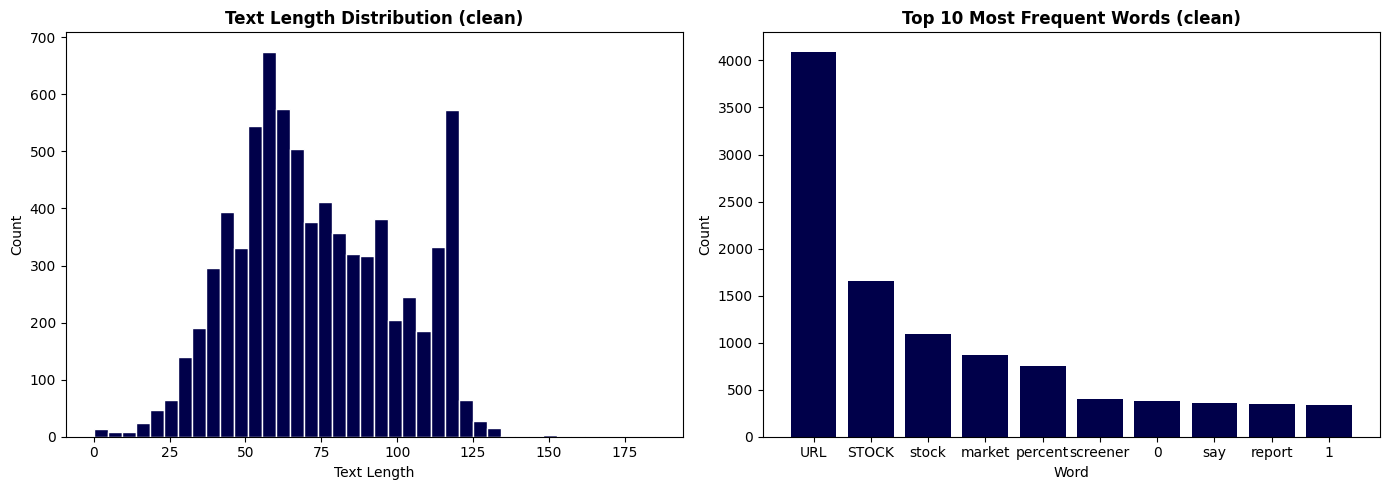

In [12]:
train["text_clean_joined"] = train['text_tokens'].apply(lambda x: " ".join(x))
freq_clean = pd.Series(' '.join(train['text_clean_joined']).split()).value_counts()

fig, ax = plt.subplots(ncols=2, figsize=(14, 5))
ax[0].hist(
         train.text_clean.str.len(),
         bins=40,
         color="#00004A",
         edgecolor="white"
         )
ax[1].bar(freq_clean.head(10).index, freq_clean.head(10).values, color="#00004A")

ax[0].set_xlabel("Text Length")
ax[0].set_ylabel("Count")
ax[0].set_title("Text Length Distribution (clean)", fontweight="bold")
ax[1].set_xlabel("Word")
ax[1].set_ylabel("Count")
ax[1].set_title("Top 10 Most Frequent Words (clean)", fontweight="bold")
plt.tight_layout()
plt.savefig(r"plots/clean_distributions.png")
plt.show()

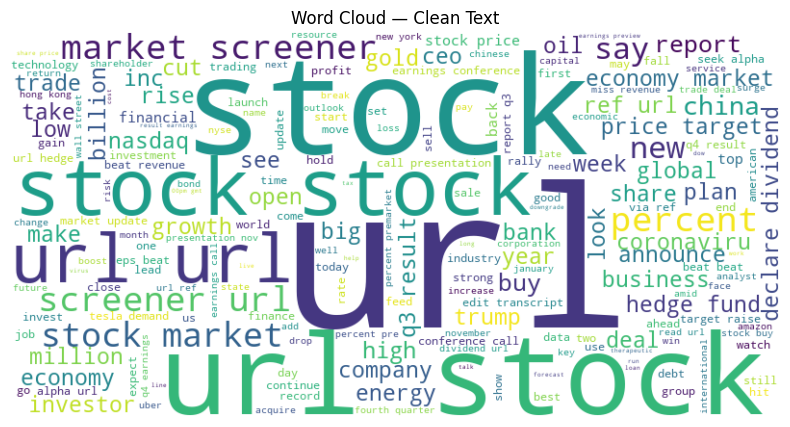

In [13]:
raw_text = ' '.join(train["text_clean_joined"]).lower()
raw_wc = WordCloud(width=800, height=400, background_color='white').generate(raw_text)

plt.figure(figsize=(10, 5))
plt.imshow(raw_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Clean Text')
plt.savefig(r"plots/clean_wordcloud.png")
plt.show()

### Encoding
todo: should there be umap?

In [14]:
train_bow, bow_encoder = encode_bow(train["text_tokens"])
train_vec = ...
train_trans = ...

train_label = train["label"]

In [15]:
# this is wrong
validation_bow = encode_bow(validation["text_tokens"], 
                            encoder=bow_encoder, 
                            return_bow=False)
validation_vec = ...
validation_trans = ...

validation_label = validation["label"]

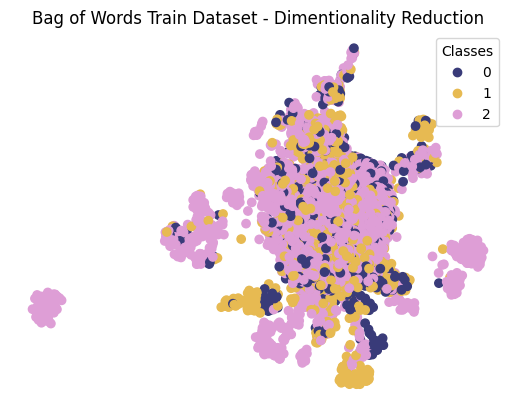

In [16]:
umap_object = umap.UMAP(n_neighbors=25, min_dist=0.95, random_state=SEED) 
umap_embedding = umap_object.fit_transform(train_bow.values)
visualize_dimensionality_reduction(umap_embedding, 
                                   train_label, 
                                   title="Bag of Words Train Dataset - Dimentionality Reduction")

## Training